# Лабораторная работа 6. Понижение размерности. Задача классификации

In [1]:
import pandas as pd
from imblearn.combine import SMOTEENN
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

data = pd.read_csv('datasets/neo.csv', index_col=0)
data

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,-0.889019,-0.892421,0.316109,-1.612480,0.892109,0
1,-0.405274,-0.407831,-1.593181,-0.196165,0.406521,0
2,0.043918,0.042145,0.286110,1.266990,-0.044382,0
3,-0.750806,-0.753967,-0.258175,-1.094244,0.753369,0
4,0.734983,0.734416,0.777089,1.531822,-0.738079,0
...,...,...,...,...,...,...
90831,-0.819912,-0.823194,-0.982506,-1.585159,0.822739,0
90832,0.562217,0.561348,-0.921528,-0.158712,-0.564655,0
90833,-0.301614,-0.303991,2.706200,0.789522,0.302466,0
90834,-0.128848,-0.130923,-0.090366,-0.452655,0.129042,0


In [3]:
from sklearn.model_selection import train_test_split
X, y = data.drop("hazardous", axis=1), data["hazardous"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
from sklearn.metrics import f1_score

metrics = ["f1", "Accuracy", "Precision", "Recall"]
columns = [type_of_data + " " + metric for type_of_data in ["Train", "Test"] for metric in metrics]
table = pd.DataFrame(columns=columns)


def get_scores(X, y, model):
    f1 = round(f1_score(y, model.predict(X)), 2)
    acc = round(accuracy_score(y, model.predict(X)), 4)
    pr = round(precision_score(y, model.predict(X)), 4)
    rec = round(recall_score(y, model.predict(X)), 4)
    return f1, acc, pr, rec

def input_into_table(X_train, X_test, y_train, y_test, model, name):
    train_scores = get_scores(X_train, y_train, model)
    test_scores = get_scores(X_test, y_test, model)

    table.loc[name] = train_scores + test_scores

## Понижение размерности

### VarianceThreshold

C:\Users\79585\AppData\Local\Temp\ipykernel_2008\184370451.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variances.index, y=variances.values, palette='viridis')


Text(0, 0.5, 'Variance')

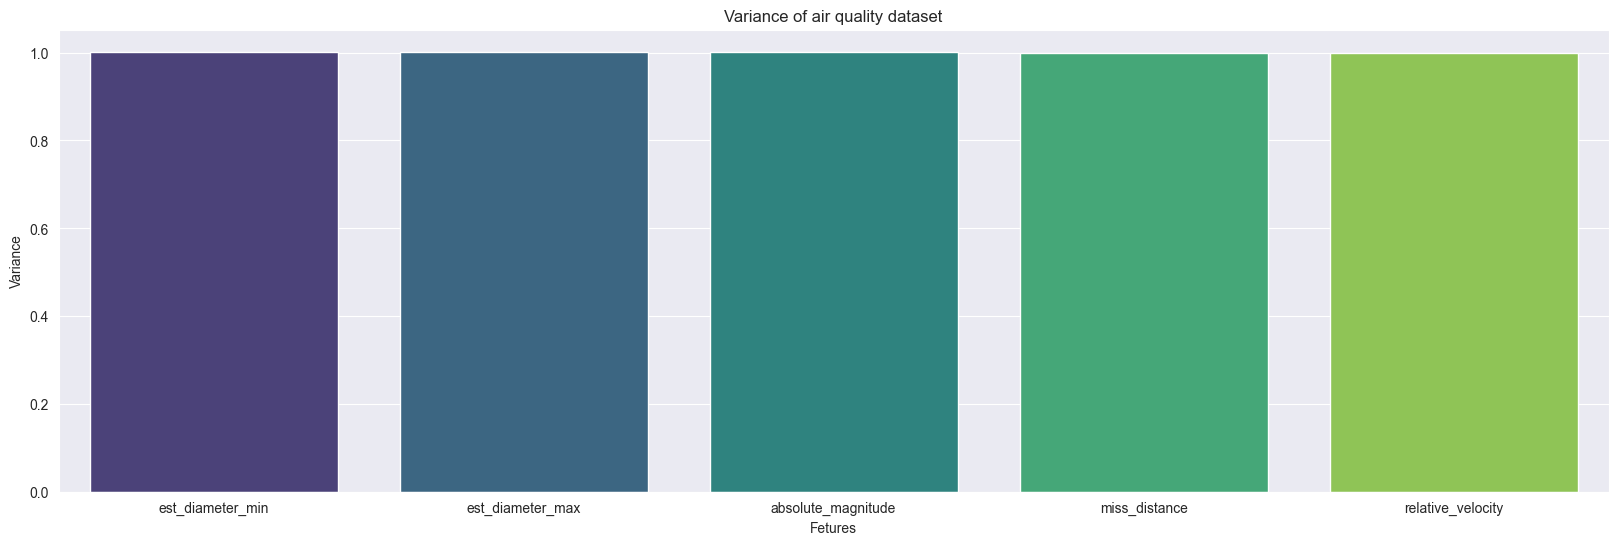

In [4]:
from matplotlib import pyplot as plt
import seaborn as sns

variances = X_train.var().sort_values(ascending=False)


plt.figure(figsize=(20, 6))
sns.barplot(x=variances.index, y=variances.values, palette='viridis')
plt.title("Variance of air quality dataset")
plt.xlabel("Fetures")
plt.ylabel("Variance")

In [5]:
from sklearn.feature_selection import VarianceThreshold

selector_vt = VarianceThreshold(threshold=1)
selector_vt.fit(X_train)

X_vt = selector_vt.transform(X_train)
selected_features = X_train.columns[selector_vt.get_support()]
print(f"Исходная размерность: {len(X_train.columns)}, оптимизированная размерность: {len(selected_features)}")
print("Отобранные признаки: ")
print(selected_features.tolist())

Исходная размерность: 5, оптимизированная размерность: 3
Отобранные признаки: 
['est_diameter_min', 'est_diameter_max', 'absolute_magnitude']


In [6]:
best_params = {
    'n_estimators': 500,
    'learning_rate': 0.6229361563509381
}

X_test_vt = selector_vt.transform(X_test)

X_vt_res, y_train_res = SMOTEENN().fit_resample(X_vt, y_train)
model = AdaBoostClassifier(**best_params)
model.fit(X_vt_res, y_train_res)
input_into_table(X_vt, X_test_vt, y_train, y_test, model, name="VarianceThreshold")
table

,Train f1,Train Accuracy,Train Precision,Train Recall,Test f1,Test Accuracy,Test Precision,Test Recall
VarianceThreshold,0.41,0.8399,0.3178,0.5596,0.39,0.8364,0.307,0.5525


Text(0.5, 0.98, 'VarianceThreshold')

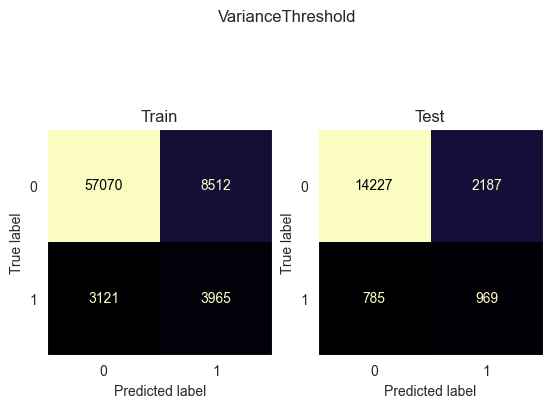

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2)
ConfusionMatrixDisplay.from_estimator(model, X_vt, y_train, colorbar=False, cmap="magma", ax=ax[0])
ax[0].set_title("Train")
ax[0].grid(False)

ConfusionMatrixDisplay.from_estimator(model, X_test_vt, y_test, colorbar=False, cmap="magma", ax=ax[1])
ax[1].set_title("Test")
ax[1].grid(False)
plt.suptitle("VarianceThreshold")

### SelectKBest

C:\Users\79585\AppData\Local\Temp\ipykernel_2008\2509319964.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(feature_importance, x="Features", y="Importance", palette='Set1')


Text(0.5, 1.0, 'Feature importances (Select KBest)')

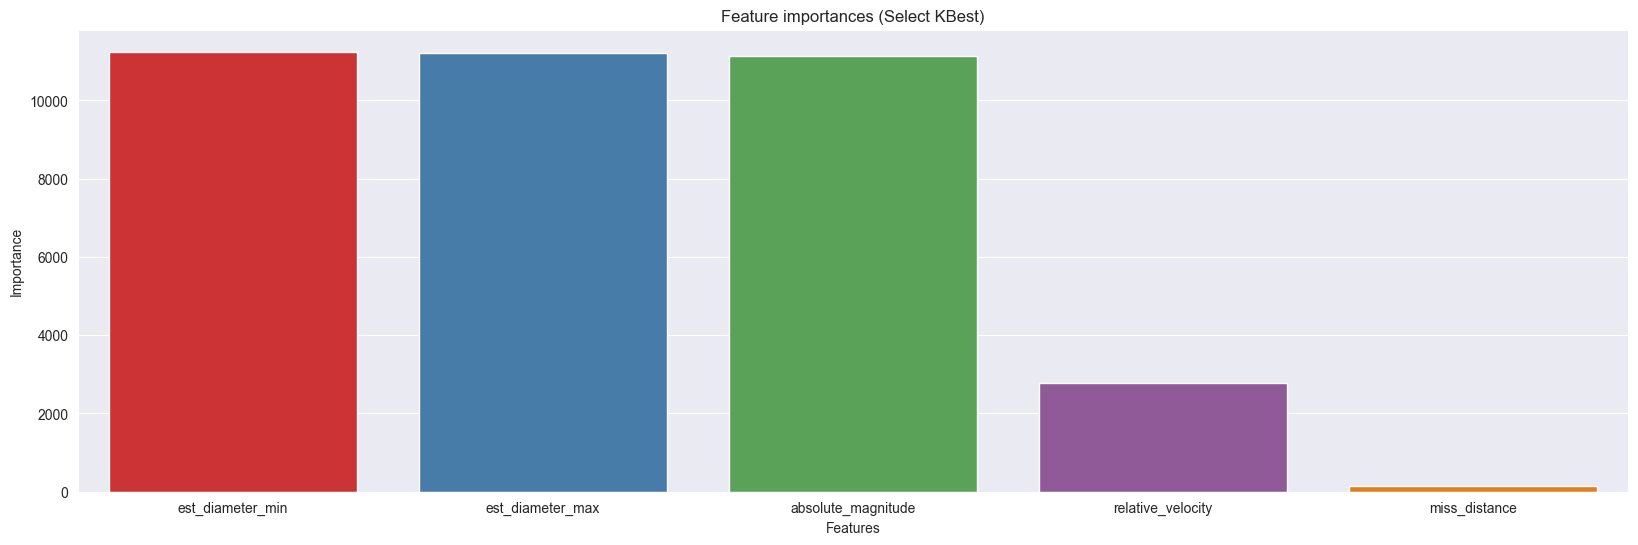

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

selector_skb = SelectKBest(score_func=f_classif, k=3)

selected_features_skb = selector_skb.fit_transform(X_train, y_train)

feature_importance = pd.DataFrame({"Features": X_train.columns, "Importance": selector_skb.scores_})
feature_importance.sort_values("Importance", ascending=False, inplace=True)
plt.figure(figsize=(20, 6))
sns.barplot(feature_importance, x="Features", y="Importance", palette='Set1')
plt.title("Feature importances (Select KBest)")

In [9]:
X.columns[selector_skb.get_support()]

Index(['est_diameter_min', 'est_diameter_max', 'absolute_magnitude'], dtype='str')

In [10]:

X_train_skb = selector_skb.transform(X_train)

X_train_skb_res, y_train_res = SMOTEENN().fit_resample(X_train_skb, y_train)
X_test_skb = selector_skb.transform(X_test)

model = AdaBoostClassifier(**best_params)
model.fit(X_train_skb_res, y_train_res)
input_into_table(X_train_skb, X_test_skb, y_train, y_test, model, name="SelectKBest")
table

,Train f1,Train Accuracy,Train Precision,Train Recall,Test f1,Test Accuracy,Test Precision,Test Recall
VarianceThreshold,0.41,0.8399,0.3178,0.5596,0.39,0.8364,0.3070,0.5525
SelectKBest,0.41,0.8306,0.3119,0.6115,0.41,0.8293,0.3058,0.6049


Text(0.5, 0.98, 'Select KBest')

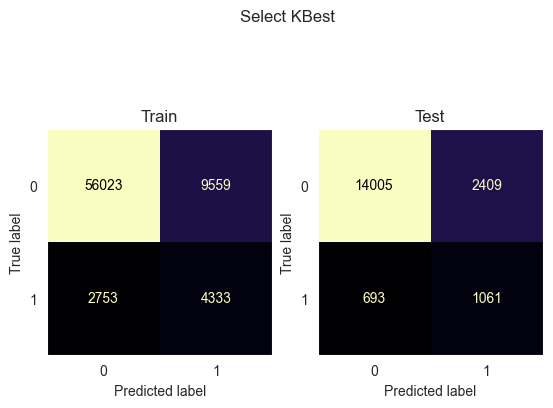

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2)
ConfusionMatrixDisplay.from_estimator(model, X_train_skb, y_train, colorbar=False, cmap="magma", ax=ax[0])
ax[0].set_title("Train")
ax[0].grid(False)

ConfusionMatrixDisplay.from_estimator(model, X_test_skb, y_test, colorbar=False, cmap="magma", ax=ax[1])
ax[1].set_title("Test")
ax[1].grid(False)
plt.suptitle("Select KBest")

### RFE

C:\Users\79585\AppData\Local\Temp\ipykernel_2008\855941999.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Feature', data=rfe_data, palette='viridis')


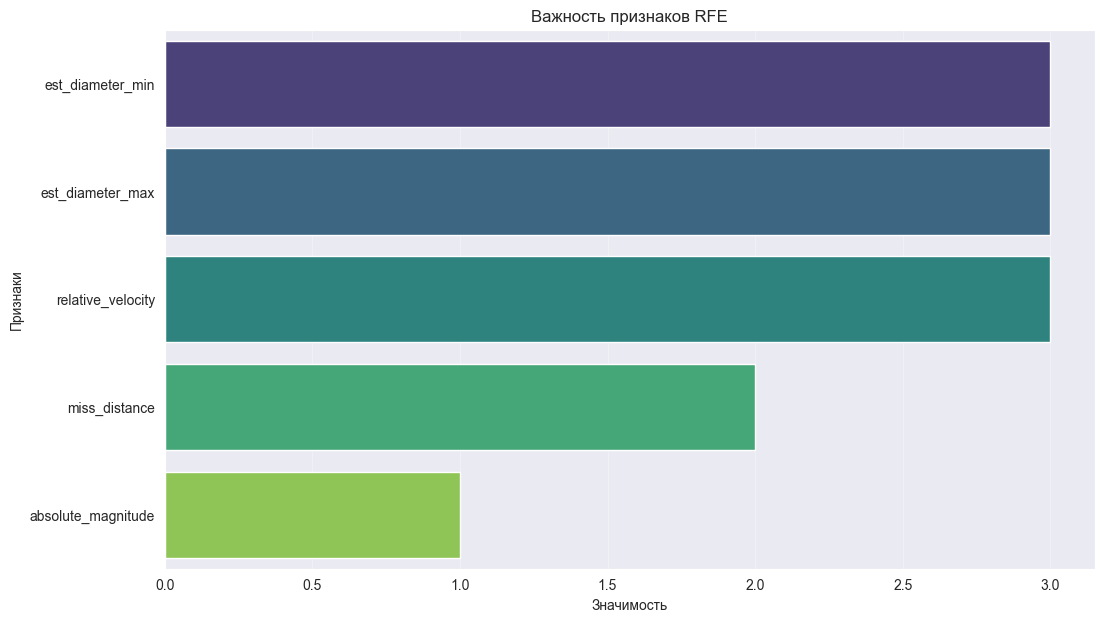

In [12]:
from sklearn.feature_selection import RFE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model = AdaBoostClassifier(**best_params)
selector_rfe = RFE(estimator=model, n_features_to_select=3, step=1)

X_train_res, y_train_res = SMOTEENN().fit_resample(X_train, y_train)

selected_features = selector_rfe.fit_transform(X_train, y_train)

rfe_data = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': selector_rfe.ranking_
})


rfe_data['Importance_Score'] = rfe_data['Rank'].max() - rfe_data['Rank'] + 1
rfe_data = rfe_data.sort_values('Importance_Score', ascending=False)


plt.figure(figsize=(12, 7))
sns.barplot(x='Importance_Score', y='Feature', data=rfe_data, palette='viridis')

plt.title('Важность признаков RFE')
plt.xlabel('Значимость')
plt.ylabel('Признаки')
plt.grid(axis='x', alpha=0.3)
plt.show()


In [13]:
chosen_features = X_train.columns[selector_rfe.get_support()].tolist()

print(f"Выбранные признаки: {chosen_features}")

Выбранные признаки: ['est_diameter_min', 'est_diameter_max', 'relative_velocity']


In [14]:
X_train_rfe = selector_rfe.transform(X_train)

X_train_rfe_res, y_train_res = SMOTEENN().fit_resample(X_train_rfe, y_train)
X_test_rfe = selector_rfe.transform(X_test)
model = AdaBoostClassifier(**best_params)
model.fit(X_train_rfe_res, y_train_res)
input_into_table(X_train_rfe, X_test_rfe, y_train, y_test, model, name="RFE")
table

,Train f1,Train Accuracy,Train Precision,Train Recall,Test f1,Test Accuracy,Test Precision,Test Recall
VarianceThreshold,0.41,0.8399,0.3178,0.5596,0.39,0.8364,0.3070,0.5525
SelectKBest,0.41,0.8306,0.3119,0.6115,0.41,0.8293,0.3058,0.6049
RFE,0.47,0.7834,0.3091,0.9889,0.47,0.7813,0.3049,0.9886


Text(0.5, 0.98, 'RFE')

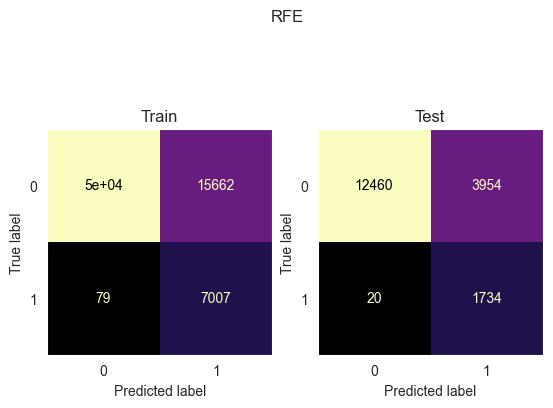

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2)
ConfusionMatrixDisplay.from_estimator(model, X_train_rfe, y_train, colorbar=False, cmap="magma", ax=ax[0])
ax[0].set_title("Train")
ax[0].grid(False)

ConfusionMatrixDisplay.from_estimator(model, X_test_rfe, y_test, colorbar=False, cmap="magma", ax=ax[1])
ax[1].set_title("Test")
ax[1].grid(False)
plt.suptitle("RFE")

### PCA

In [4]:
from sklearn.decomposition import PCA, KernelPCA

pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train)

print(f"Размерность до PCA: {X_train.shape[1]}")
print(f"Размерность после PCA: {X_train_pca.shape[1]}")

exp_var = pca.explained_variance_ratio_

Размерность до PCA: 5
Размерность после PCA: 3


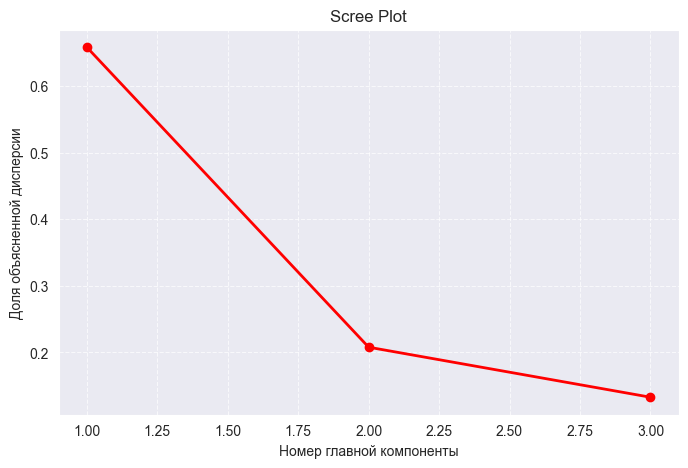

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(exp_var) + 1), exp_var, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объясненной дисперсии')


plt.grid(True, linestyle='--', alpha=0.7)


plt.show()

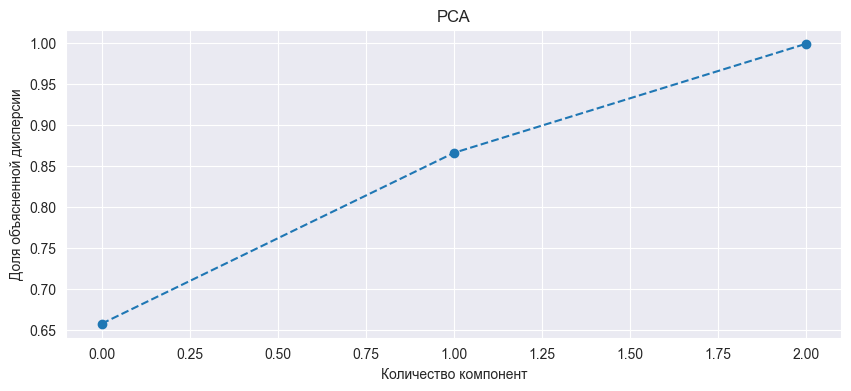

In [17]:
import numpy as np

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('РСА')
plt.xlabel('Количество компонент')
plt.ylabel('Доля объясненной дисперсии')
plt.show()


In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X_train.columns
)

print("Вклад исходных признаков в каждую компоненту:")
print(loadings)

Вклад исходных признаков в каждую компоненту:
                         PC1       PC2       PC3
est_diameter_min    0.539212 -0.202619 -0.042203
est_diameter_max    0.538848 -0.203200 -0.042302
relative_velocity   0.280205  0.583338  0.762365
miss_distance       0.225186  0.732075 -0.642928
absolute_magnitude -0.538211  0.203562  0.043271


In [19]:
X_train_pca = pca.transform(X_train)
X_train_pca_res, y_train_res = SMOTEENN().fit_resample(X_train_pca, y_train)
X_test_pca = pca.transform(X_test)

model = AdaBoostClassifier(**best_params)
model.fit(X_train_pca, y_train)
input_into_table(X_train_pca_res, X_test_pca, y_train_res, y_test, model, name="PCA")
table

,Train f1,Train Accuracy,Train Precision,Train Recall,Test f1,Test Accuracy,Test Precision,Test Recall
VarianceThreshold,0.41,0.8399,0.3178,0.5596,0.39,0.8364,0.3070,0.5525
SelectKBest,0.41,0.8306,0.3119,0.6115,0.41,0.8293,0.3058,0.6049
RFE,0.47,0.7834,0.3091,0.9889,0.47,0.7813,0.3049,0.9886
PCA,0.16,0.5213,0.9921,0.0876,0.15,0.9066,0.6135,0.0878


Text(0.5, 0.98, 'PCA')

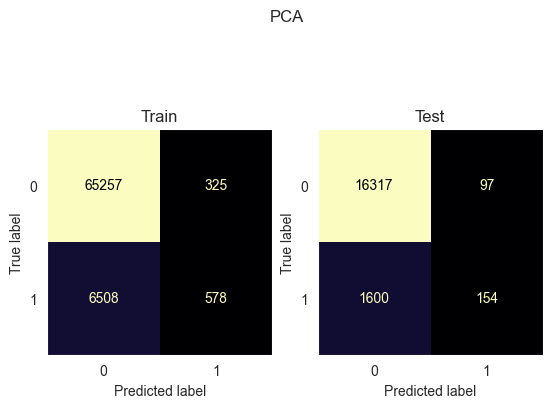

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2)
ConfusionMatrixDisplay.from_estimator(model, X_train_pca, y_train, colorbar=False, cmap="magma", ax=ax[0])
ax[0].set_title("Train")
ax[0].grid(False)

ConfusionMatrixDisplay.from_estimator(model, X_test_pca, y_test, colorbar=False, cmap="magma", ax=ax[1])
ax[1].set_title("Test")
ax[1].grid(False)
plt.suptitle("PCA")

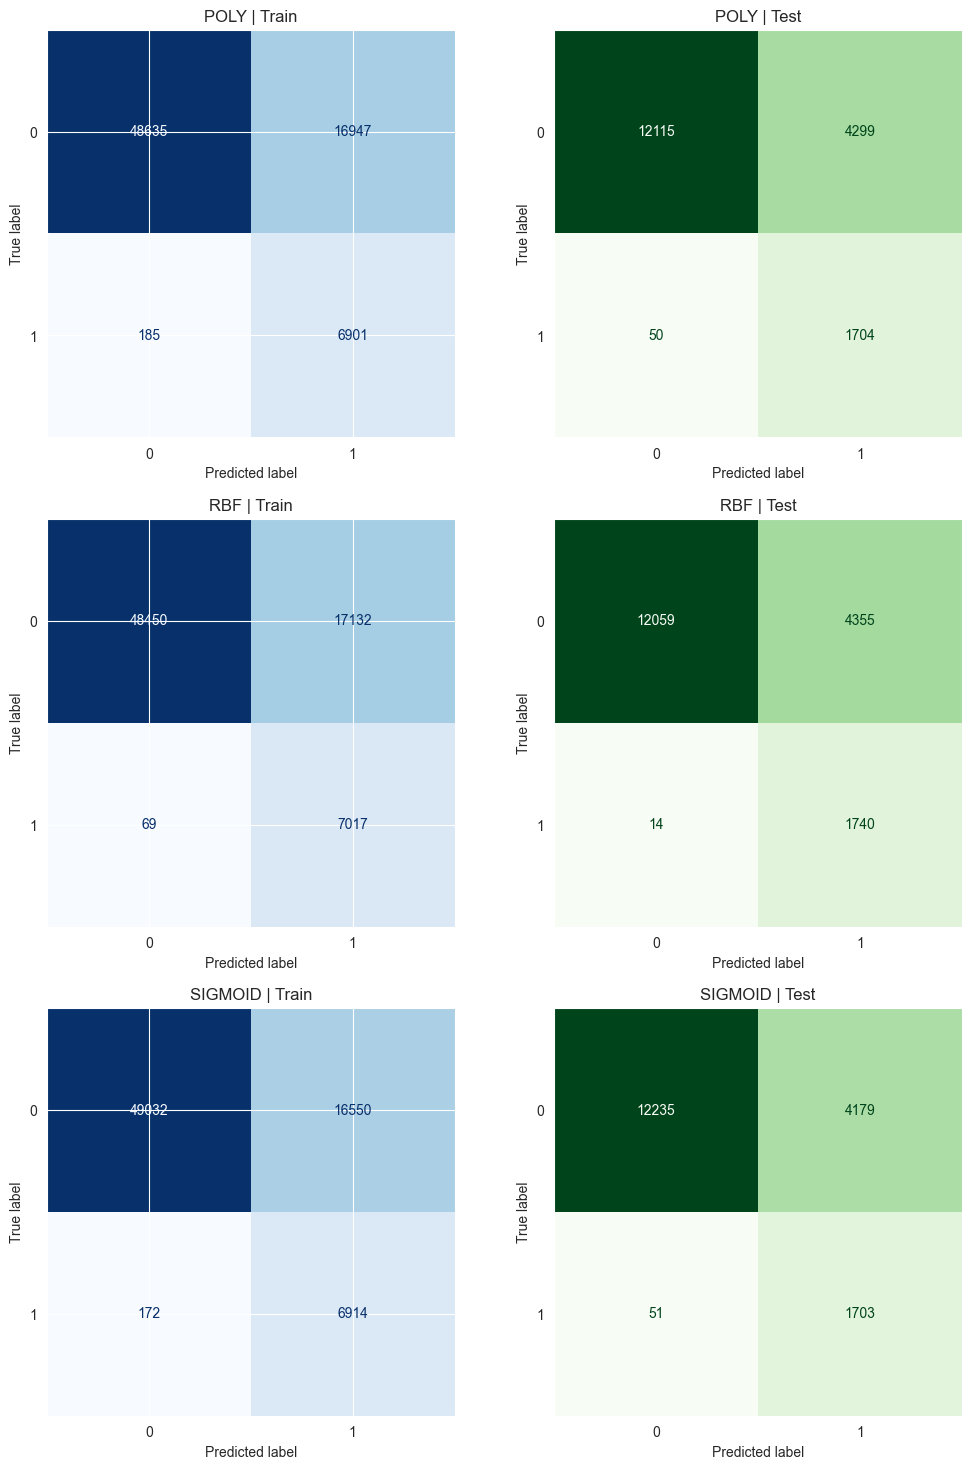

In [21]:
import matplotlib.pyplot as plt
from sklearn.kernel_approximation import Nystroem

kernels = {
    'poly':    {'degree': 2},
    'rbf':     {},
    'sigmoid': {}
}

fig, axes = plt.subplots(3, 2, figsize=(12, 18))
kernel_selector = []
for i, kernel_info in enumerate(kernels.items()):
    kernel, kernel_params = kernel_info

    kpca = Nystroem(kernel=kernel, n_jobs=-1, **kernel_params, n_components=10)
    kpca.fit(X_train)
    kernel_selector.append(kpca)


    X_train_selected = kpca.transform(X_train)
    X_test_selected  = kpca.transform(X_test)
    X_train_selected_res, y_train_res = SMOTEENN().fit_resample(X_train_selected, y_train)
    model = AdaBoostClassifier(**best_params)
    model.fit(X_train_selected_res, y_train_res)
    input_into_table(X_train_selected, X_test_selected, y_train, y_test, model, name=f"PCA {kernel}")

    ConfusionMatrixDisplay.from_estimator(model, X_train_selected, y_train,
                                          ax=axes[i, 0], cmap='Blues', colorbar=False)
    axes[i, 0].set_title(f'{kernel.upper()} | Train')
    axes[i, 1].grid(False)

    ConfusionMatrixDisplay.from_estimator(model, X_test_selected, y_test,
                                          ax=axes[i, 1], cmap='Greens', colorbar=False)
    axes[i, 1].set_title(f'{kernel.upper()} | Test')
    axes[i, 1].grid(False)


In [22]:
table

,Train f1,Train Accuracy,Train Precision,Train Recall,Test f1,Test Accuracy,Test Precision,Test Recall
VarianceThreshold,0.41,0.8399,0.3178,0.5596,0.39,0.8364,0.3070,0.5525
SelectKBest,0.41,0.8306,0.3119,0.6115,0.41,0.8293,0.3058,0.6049
RFE,0.47,0.7834,0.3091,0.9889,0.47,0.7813,0.3049,0.9886
PCA,0.16,0.5213,0.9921,0.0876,0.15,0.9066,0.6135,0.0878
PCA poly,0.45,0.7642,0.2894,0.9739,0.44,0.7606,0.2839,0.9715
PCA rbf,0.45,0.7633,0.2906,0.9903,0.44,0.7595,0.2855,0.9920
PCA sigmoid,0.45,0.7699,0.2947,0.9757,0.45,0.7672,0.2895,0.9709


### UMAP

In [23]:
from umap import UMAP

umap = UMAP(n_components=3, random_state=42)
X_umap_train = umap.fit_transform(X_train)
X_umap_test = umap.transform(X_test)
X_umap_train_res, y_train_res = SMOTEENN().fit_resample(X_umap_train, y_train)
model = AdaBoostClassifier(**best_params)
model.fit(X_umap_train_res, y_train_res)
input_into_table(X_umap_train, X_umap_test, y_train, y_test, model, name="UMAP")
table

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,Train f1,Train Accuracy,Train Precision,Train Recall,Test f1,Test Accuracy,Test Precision,Test Recall
VarianceThreshold,0.41,0.8399,0.3178,0.5596,0.39,0.8364,0.3070,0.5525
SelectKBest,0.41,0.8306,0.3119,0.6115,0.41,0.8293,0.3058,0.6049
RFE,0.47,0.7834,0.3091,0.9889,0.47,0.7813,0.3049,0.9886
PCA,0.16,0.5213,0.9921,0.0876,0.15,0.9066,0.6135,0.0878
PCA poly,0.45,0.7642,0.2894,0.9739,0.44,0.7606,0.2839,0.9715
PCA rbf,0.45,0.7633,0.2906,0.9903,0.44,0.7595,0.2855,0.9920
PCA sigmoid,0.45,0.7699,0.2947,0.9757,0.45,0.7672,0.2895,0.9709
UMAP,0.44,0.7502,0.2796,0.9910,0.43,0.7455,0.2737,0.9897


Text(0.5, 0.98, 'UMAP')

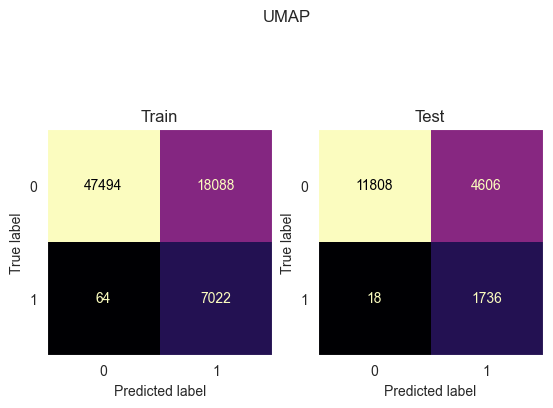

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2)
ConfusionMatrixDisplay.from_estimator(model, X_umap_train, y_train, colorbar=False, cmap="magma", ax=ax[0])
ax[0].set_title("Train")
ax[0].grid(False)

ConfusionMatrixDisplay.from_estimator(model, X_umap_test, y_test, colorbar=False, cmap="magma", ax=ax[1])
ax[1].set_title("Test")
ax[1].grid(False)
plt.suptitle("UMAP")

### t-SNE

<Axes: >

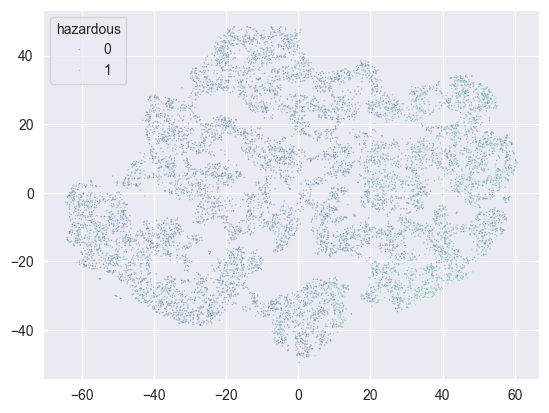

In [26]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=100, random_state=42)
X_tsne = tsne.fit_transform(X)

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis', alpha=0.5, s=1)


In [28]:
X_tsne_train = X_tsne[:len(X_train)]
X_tsne_test = X_tsne[len(X_train):]

X_tsne_train_res, y_train_res = SMOTEENN().fit_resample(X_tsne_train, y_train)

model = AdaBoostClassifier(**best_params)
model.fit(X_tsne_train_res, y_train_res)

input_into_table(X_tsne_train, X_tsne_test, y_train, y_test, model, name="t-SNE")
table

,Train f1,Train Accuracy,Train Precision,Train Recall,Test f1,Test Accuracy,Test Precision,Test Recall
VarianceThreshold,0.41,0.8399,0.3178,0.5596,0.39,0.8364,0.3070,0.5525
SelectKBest,0.41,0.8306,0.3119,0.6115,0.41,0.8293,0.3058,0.6049
RFE,0.47,0.7834,0.3091,0.9889,0.47,0.7813,0.3049,0.9886
PCA,0.16,0.5213,0.9921,0.0876,0.15,0.9066,0.6135,0.0878
PCA poly,0.45,0.7642,0.2894,0.9739,0.44,0.7606,0.2839,0.9715
PCA rbf,0.45,0.7633,0.2906,0.9903,0.44,0.7595,0.2855,0.9920
PCA sigmoid,0.45,0.7699,0.2947,0.9757,0.45,0.7672,0.2895,0.9709
UMAP,0.44,0.7502,0.2796,0.9910,0.43,0.7455,0.2737,0.9897
t-SNE,0.20,0.2954,0.1121,0.8170,0.16,0.2720,0.0890,0.7624


### Isomap

In [29]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=3, n_neighbors=10)
X_isomap_train = isomap.fit_transform(X_train)
X_isomap_test = isomap.transform(X_test)

In [30]:
model = AdaBoostClassifier(**best_params)
X_isomap_train_res, y_train_res = SMOTEENN().fit_resample(X_isomap_train, y_train)
model.fit(X_isomap_train_res, y_train_res)
input_into_table(X_isomap_train, X_isomap_test, y_train, y_test, model, name="Isomap")
table

,Train f1,Train Accuracy,Train Precision,Train Recall,Test f1,Test Accuracy,Test Precision,Test Recall
VarianceThreshold,0.41,0.8399,0.3178,0.5596,0.39,0.8364,0.3070,0.5525
SelectKBest,0.41,0.8306,0.3119,0.6115,0.41,0.8293,0.3058,0.6049
RFE,0.47,0.7834,0.3091,0.9889,0.47,0.7813,0.3049,0.9886
PCA,0.16,0.5213,0.9921,0.0876,0.15,0.9066,0.6135,0.0878
PCA poly,0.45,0.7642,0.2894,0.9739,0.44,0.7606,0.2839,0.9715
PCA rbf,0.45,0.7633,0.2906,0.9903,0.44,0.7595,0.2855,0.9920
PCA sigmoid,0.45,0.7699,0.2947,0.9757,0.45,0.7672,0.2895,0.9709
UMAP,0.44,0.7502,0.2796,0.9910,0.43,0.7455,0.2737,0.9897
t-SNE,0.20,0.2954,0.1121,0.8170,0.16,0.2720,0.0890,0.7624
Isomap,0.46,0.7629,0.3048,0.9681,0.41,0.7490,0.2579,0.9448


### Кастомный PCA

In [32]:
from custom_algorithms import Pca

custom_pca = Pca(n_components=2)
custom_pca.fit(X)
X_pca = custom_pca.transform(X)

Text(0.5, 1.0, 'Custom PCA')

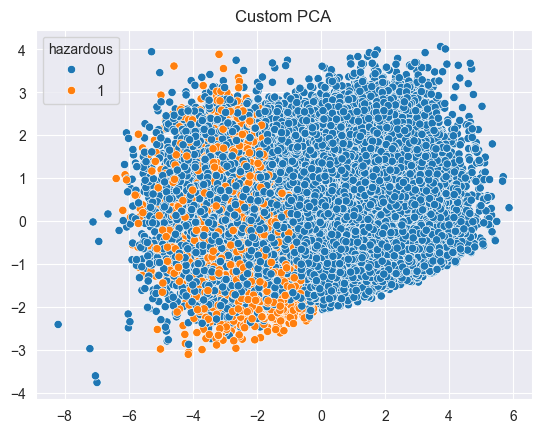

In [34]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y)
plt.title("Custom PCA")

Text(0.5, 1.0, 'Custom kmeans with PCA-transformed data')

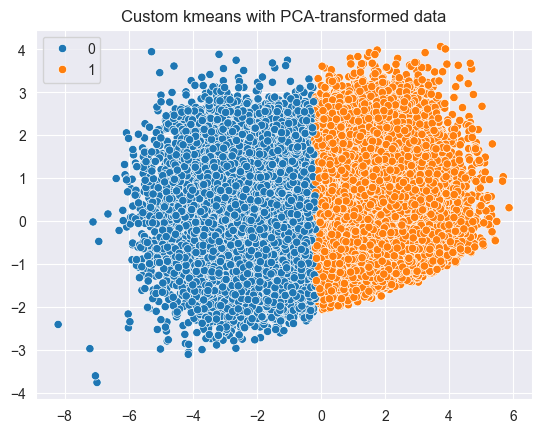

In [41]:
from custom_algorithms import kmeans

km = kmeans(k=2)
labels = km.fit(X.values)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels)

plt.title("Custom kmeans with PCA-transformed data")

## Вывод

In [42]:
table

,Train f1,Train Accuracy,Train Precision,Train Recall,Test f1,Test Accuracy,Test Precision,Test Recall
VarianceThreshold,0.41,0.8399,0.3178,0.5596,0.39,0.8364,0.3070,0.5525
SelectKBest,0.41,0.8306,0.3119,0.6115,0.41,0.8293,0.3058,0.6049
RFE,0.47,0.7834,0.3091,0.9889,0.47,0.7813,0.3049,0.9886
PCA,0.16,0.5213,0.9921,0.0876,0.15,0.9066,0.6135,0.0878
PCA poly,0.45,0.7642,0.2894,0.9739,0.44,0.7606,0.2839,0.9715
PCA rbf,0.45,0.7633,0.2906,0.9903,0.44,0.7595,0.2855,0.9920
PCA sigmoid,0.45,0.7699,0.2947,0.9757,0.45,0.7672,0.2895,0.9709
UMAP,0.44,0.7502,0.2796,0.9910,0.43,0.7455,0.2737,0.9897
t-SNE,0.20,0.2954,0.1121,0.8170,0.16,0.2720,0.0890,0.7624
Isomap,0.46,0.7629,0.3048,0.9681,0.41,0.7490,0.2579,0.9448
